In [1]:
!pip install pandas openpyxl

import pandas as pd
datos = pd.read_excel('TDA_PROYECTO.xlsx')

datos.head()

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


,Fecha,México,Chile,Colombia,USA
0,2004-06-01,2.33,-0.850000,1.058571,1.946576
1,2004-07-01,2.55,-0.750000,0.658293,1.933799
2,2004-08-02,2.70,-0.850000,0.577813,1.855803
3,2004-09-01,3.13,-0.859524,0.723714,1.484692
4,2004-10-01,3.47,-1.000000,0.615938,1.687106


In [2]:
!pip install giotto-tda

from gtda.time_series import SingleTakensEmbedding, SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.pipeline import make_pipeline
from gtda.plotting import plot_diagram
from gtda.diagrams import Amplitude

buscador_parametros = SingleTakensEmbedding(parameters_type='search', time_delay=15, dimension=7)

paises = ['México', 'Chile', 'Colombia', 'USA']
for pais in paises:
    serie_pais = datos[pais].values

    buscador_parametros.fit_transform(serie_pais)

    print(f"--- Resultados para {pais} ---")
    print(f"  > Retraso de tiempo (Time Delay) sugerido: {buscador_parametros.time_delay_} meses")
    print(f"  > Dimensión (Embedding Dimension) sugerida: {buscador_parametros.dimension_}\n")

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
--- Resultados para México ---
  > Retraso de tiempo (Time Delay) sugerido: 15 meses
  > Dimensión (Embedding Dimension) sugerida: 6

--- Resultados para Chile ---
  > Retraso de tiempo (Time Delay) sugerido: 13 meses
  > Dimensión (Embedding Dimension) sugerida: 5

--- Resultados para Colombia ---
  > Retraso de tiempo (Time Delay) sugerido: 13 meses
  > Dimensión (Embedding Dimension) sugerida: 4

--- Resultados para USA ---
  > Retraso de tiempo (Time Delay) sugerido: 12 meses
  > Dimensión (Embedding Dimension) sugerida: 3



Diagrama de persistencia para: USA


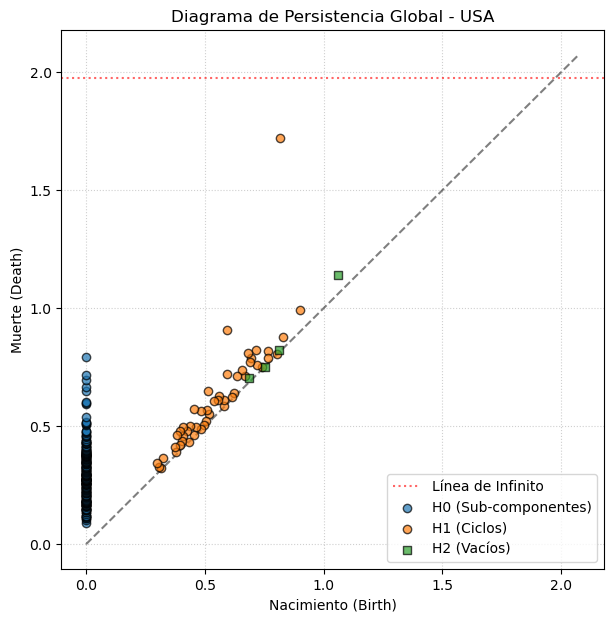

Diagrama de persistencia para: México


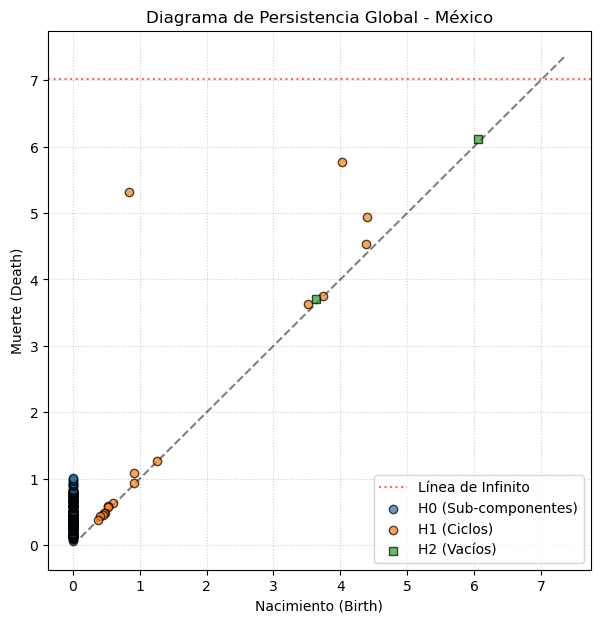

Diagrama de persistencia para: Chile


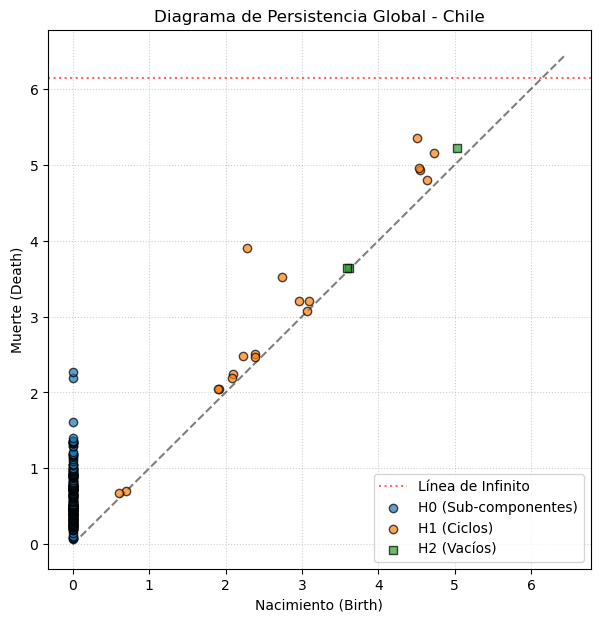

Diagrama de persistencia para: Colombia


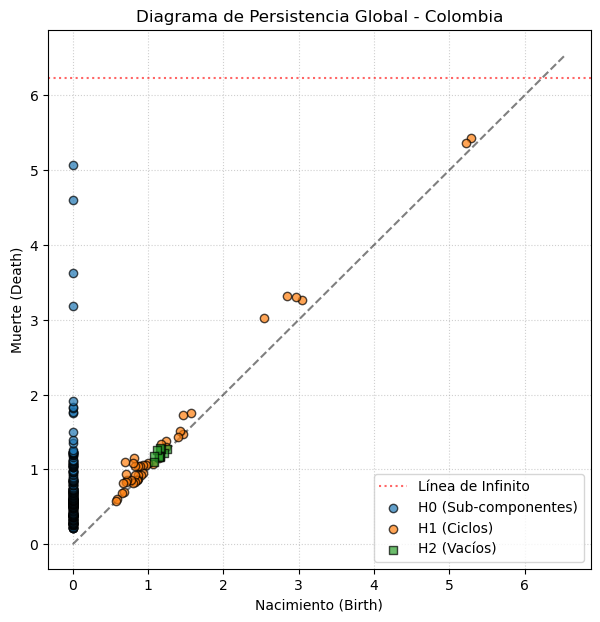

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.pipeline import make_pipeline

TE = TakensEmbedding(time_delay=12, dimension=5)
VR = VietorisRipsPersistence(homology_dimensions=[0, 1, 2])
pipeline_global = make_pipeline(TE, VR)

paises = ['USA', 'México', 'Chile', 'Colombia'] 
diagramas_globales = {}

for pais in paises:
    print(f'Diagrama de persistencia para: {pais}')
    
    # Extraemos y limpiamos la serie
    serie_limpia = pd.to_numeric(datos[pais], errors='coerce').dropna().values
    serie = serie_limpia.reshape(1, -1)
    
    # Calculamos la persistencia
    diagrama = pipeline_global.fit_transform(serie)[0]
    diagramas_globales[pais] = diagrama
    
    # Encontramos la muerte más tardía
    finitos = diagrama[diagrama[:, 1] != np.inf]
    max_muerte_finita = np.max(finitos[:, 1]) if len(finitos) > 0 else 1
    infinito_visual = max_muerte_finita * 1.15 
    
    # Hacemos copia para graficar y arreglamos los infinitos si es que giotto-tda arrojó alguno
    diagrama_plot = diagrama.copy()
    diagrama_plot[diagrama_plot[:, 1] == np.inf, 1] = infinito_visual
    
    # Separamos los puntos por su dimensión topológica
    h0 = diagrama_plot[diagrama_plot[:, 2] == 0.0] 
    h1 = diagrama_plot[diagrama_plot[:, 2] == 1.0] 
    h2 = diagrama_plot[diagrama_plot[:, 2] == 2.0] 
    
    # Quitamos la componente principal de la variable h0 (si venía) para no duplicarla
    h0_finitos = h0[h0[:, 1] < infinito_visual]
    
    plt.figure(figsize=(7, 7))
    
    # Dibujamos la línea diagonal base y la de Infinito
    plt.plot([0, infinito_visual * 1.05], [0, infinito_visual * 1.05], color='black', linestyle='--', alpha=0.5)
    plt.axhline(y=infinito_visual, color='red', linestyle=':', alpha=0.6, label='Línea de Infinito')
    
    
    # Graficamos el resto de los puntos (el "ruido" y las características finitas)
    if len(h0_finitos) > 0:
        plt.scatter(h0_finitos[:, 0], h0_finitos[:, 1], color='#1f77b4', label='H0 (Sub-componentes)', alpha=0.7, edgecolor='black', zorder=5)
        
    if len(h1) > 0:
        plt.scatter(h1[:, 0], h1[:, 1], color='#ff7f0e', label='H1 (Ciclos)', alpha=0.7, edgecolor='black', zorder=5)
        
    if len(h2) > 0:
        plt.scatter(h2[:, 0], h2[:, 1], color='#2ca02c', label='H2 (Vacíos)', alpha=0.7, edgecolor='black', marker='s', zorder=5)

    # Configuramos el diseño
    plt.title(f"Diagrama de Persistencia Global - {pais}")
    plt.xlabel("Nacimiento (Birth)")
    plt.ylabel("Muerte (Death)")
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)    

    plt.savefig(f"diagrama_{pais}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
import numpy as np
from gtda.diagrams import Amplitude

# 1. Inicializamos la herramienta de Amplitud
# Le indicamos que use la métrica de Cuello de Botella ('bottleneck')
# Por defecto, giotto-tda calculará esto para H0, H1 y H2 por separado
calculadora_amplitud = Amplitude(metric='bottleneck')

print("--- AMPLITUD TOPOLÓGICA (Métrica: Bottleneck) ---")

# Guardar los resultados
resultados_amplitud = {}

for pais in paises:
    # 2. Recuperamos el diagrama original que guardamos en el paso anterior
    diagrama_original = diagramas_globales[pais]
    
    # 3. giotto-tda requiere que los datos entren como un "lote" (batch), así que metemos el diagrama en una lista para que tenga dimensión (1, n_puntos, 3)
    diagrama_lote = np.array([diagrama_original])
    
    # 4. Calculamos la amplitud
    # Nos devolverá un arreglo con 3 números (uno por cada dimensión homológica)
    amplitud = calculadora_amplitud.fit_transform(diagrama_lote)[0]
    
    resultados_amplitud[pais] = amplitud
    
    # 5. Imprimimos los resultados de forma elegante
    print(f"\nPaís: {pais}")
    print(f"  Amplitud H0 (Componentes): {amplitud[0]:.4f}")
    print(f"  Amplitud H1 (Ciclos):      {amplitud[1]:.4f}")
    print(f"  Amplitud H2 (Vacíos):      {amplitud[2]:.4f}")

--- AMPLITUD TOPOLÓGICA (Métrica: Bottleneck) ---

País: USA
  Amplitud H0 (Componentes): 0.3969
  Amplitud H1 (Ciclos):      0.4518
  Amplitud H2 (Vacíos):      0.0394

País: México
  Amplitud H0 (Componentes): 0.5057
  Amplitud H1 (Ciclos):      2.2329
  Amplitud H2 (Vacíos):      0.0283

País: Chile
  Amplitud H0 (Componentes): 1.1366
  Amplitud H1 (Ciclos):      0.8153
  Amplitud H2 (Vacíos):      0.0973

País: Colombia
  Amplitud H0 (Componentes): 2.5338
  Amplitud H1 (Ciclos):      0.2464
  Amplitud H2 (Vacíos):      0.0652


Entrenando el pipeline con ventanas móviles primero...
¡Modelo completado! R² en el conjunto de datos: 0.9534


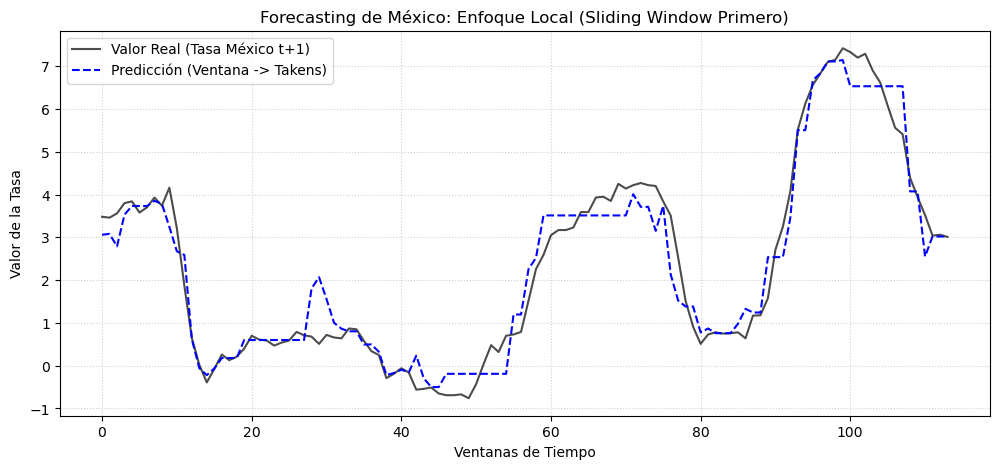

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gtda.time_series import Labeller, SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Amplitude
from sklearn.ensemble import RandomForestRegressor
from gtda.pipeline import make_pipeline

# 1. Extraer y limpiar la serie temporal de México
serie_mexico = pd.to_numeric(datos['México'], errors='coerce').dropna().values

# 2. Configurar los bloques con el nuevo orden
# El Labeller siempre va al inicio para preparar el objetivo (t+1)
lab = Labeller(size=1, func=np.max)

# Primero las ventanas moviles
# Cortamos la serie de tiempo en ventanas (ej. 12 meses) antes de hacer la geometría
sw = SlidingWindow(size=36, stride=2)

# Proceder con la Inscrustación de Taken
# Usamos TakensEmbedding (en lugar de Single) porque va a recibir muchas ventanas juntas.
# Nota: Aquí fijamos los parámetros (delay=2, dimension=3) ya que buscar automáticamente 
# parámetros ventana por ventana tendría mucho costo computacional.
te = TakensEmbedding(time_delay=2, dimension=6)

# Persistencia, Amplitud y Modelo
vr = VietorisRipsPersistence(homology_dimensions=[0, 1, 2])
ampl = Amplitude()
rfr = RandomForestRegressor(random_state = 42)

# 3. Construcción del Pipeline
# Labeller -> SlidingWindow -> TakensEmbedding -> VR -> Amplitude -> Regresor
pipeline_local = make_pipeline(lab, sw, te, vr, ampl, rfr)

# 4. Ajustar el modelo
print("Entrenando el pipeline con ventanas móviles primero...")
pipeline_local.fit(serie_mexico, serie_mexico)

# 5. Predecir
predicciones_locales = pipeline_local.predict(serie_mexico)

# Alineamos los valores reales para la gráfica
_, y_real_alineado = pipeline_local[:-1].transform_resample(serie_mexico, serie_mexico)

score = pipeline_local.score(serie_mexico, serie_mexico)
print(f"¡Modelo completado! R² en el conjunto de datos: {score:.4f}")

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(y_real_alineado, label="Valor Real (Tasa México t+1)", color="black", alpha=0.7)
plt.plot(predicciones_locales, label="Predicción (Ventana -> Takens)", color="blue", linestyle="--")
plt.title("Forecasting de México: Enfoque Local (Sliding Window Primero)")
plt.xlabel("Ventanas de Tiempo")
plt.ylabel("Valor de la Tasa")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig(f"predicción_méxico.png", dpi=300, bbox_inches='tight')

plt.show()

In [12]:
prediccion_futura = predicciones_locales[-1]

print (f"---: {prediccion_futura: .4f}")

---:  3.0197
